# **Asignatura**: Aprendizaje Automático

**Práctica 2**: Aprendizaje no supervisado.

**Valoración máxima**: 10 puntos

**Fecha límite de entrega**: 25 de Abril de 2025 a las 23:59

**Procedimiento de entrega**: a través de PRADO

### Nombre completo: <mark>CRUZ LORENZO, JOAQUÍN</mark>






**Normas de desarrollo y entrega de trabajos**

- Única y exclusivamente se debe entregar este Notebook de Colab (fichero `.ipynb`). **No es necesario entregar ninguna memoria externa** (por ejemplo, en `.pdf`).

- El código debe estar bien comentado (explicando lo que realizan los distintos apartados y/o bloques), y todas las decisiones tomadas y el trabajo desarrollado (incluyendo los conceptos fundamentales subyacentes) deben documentarse ampliamente en celdas de texto. Es obligatorio documentar las valoraciones y decisiones adoptadas en el desarrollo de cada uno de los apartados. Debe incluirse también tanto una descripción de las principales funciones (Python/scikit-learn) empleadas (para mostrar que el alumno comprende, a nivel técnico, lo que está haciendo), como una valoración razonada sobre la calidad de los resultados obtenidos. **Sin esta documentación, se considera que el trabajo NO ha sido presentado**.

- La entrega en PRADO está configurada para permitir sucesivas entregas de la práctica. Desde este punto de vista, se recomienda subir versiones de la práctica a medida que se van realizando los distintos ejercicios propuestos, y no dejarlo todo para el final.  

- Se debe respetar la estructura y secciones del Notebook. Esto servirá para agilizar las correcciones, así como para identificar con facilidad qué ejercicio/apartado se está respondiendo.

- El código **NO debe escribir nada a disco**.

- El **path de lectura desde Google Drive debe ser siempre el mismo**, que es el que se indica en este Notebook.

- Una entrega es apta para ser corregida si se puede ejecutar de principio a fin sin errores. Es decir, un ejercicio con errores de ejecución tendrá una calificación de 0.

- No es válido usar opciones en las entradas (es decir, utilizar el comando `input()`, por ejemplo, para que el usuario escoja el valor de las variables para ejecutar el programa). Para ello, se deben fijar al comienzo los valores
por defecto que se consideren óptimos o que se soliciten en el enunciado.

- Se entrega solamente este Notebook, y no los datos empleados.


# **Ejercicio 1: Agrupamiento (5 puntos)**

En este ejercicio los alumnos se enfrentarán a un problema de agrupamiento, el cual tendrán que abordar de comienzo a fin (desde el análisis exploratorio hasta el entrenamiento y validación de los modelos de aprendizaje automático seleccionados). En particular, se enfrentarán a un problema real de uso de técnicas de aprendizaje automático para tratar de abstraer un conjunto de datos de modo que estos puedan agruparse en categorías o *clusters*. El conjunto de datos original se obteniene a partir de la investigación realizada en el siguiente artículo:

- Azzalini, A. and Bowman, A. W. (1990). A look at some data on the Old Faithful geyser. Applied Statistics 39, 357-365 (URL: <a href="https://www.jstor.org/stable/2347385?origin=crossref&seq=1">https://www.jstor.org/stable/2347385?origin=crossref&seq=1</a>.

## Contexto y motivación del problema

Un **géiser** es una fuente de agua caliente que, de manera intermitente, expulsa vapor y agua a presión hacia el aire. Esto ocurre cuando el agua subterránea se calienta por el magma o rocas calientes. Cuando la presión se acumula lo suficiente, el agua se libera en forma de erupción. Los géiseres son fenómenos naturales fascinantes y se pueden encontrar en lugares como Yellowstone en Estados Unidos.

<center>
<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/5/51/Yellowstone_National_Park_%28WY%2C_USA%29%2C_Old_Faithful_Geyser_--_2022_--_2599.jpg/250px-Yellowstone_National_Park_%28WY%2C_USA%29%2C_Old_Faithful_Geyser_--_2022_--_2599.jpg" />
</center>

En particular, el conocido como *Old Faithful* es uno de los géiseres más famosos del mundo y se encuentra en el Parque Nacional Yellowstone, en Estados Unidos. Su nombre, que significa "Viejo Fiel", se debe a su regularidad en las erupciones, que ocurren aproximadamente cada 90 minutos, aunque el tiempo puede variar un poco.

Las erupciones de Old Faithful pueden alcanzar alturas de entre 30 y 55 metros, y suelen durar entre 1.5 y 5 minutos. Este géiser es conocido por su confiabilidad, lo que lo convierte en una atracción popular para los visitantes del parque. Además de su impresionante actividad, el área que lo rodea está llena de otras características geotérmicas, como fumarolas y piscinas de agua caliente.

Old Faithful ha sido objeto de estudio durante más de un siglo, y su actividad es monitorizada para entender mejor los procesos geotérmicos. Esta monitorización, a nivel básico, contempla dos tipos de medidas:

- El tiempo que transcurre entre dos erupciones consecutivas, medido en minutos.
- La duración de una erupción (en minutos).


## El conjunto de datos

El conjunto de datos que vamos a utilizar contiene 272 muestras de dos valores de monitorización del Geyser *Old Faithful* y, en particular, la duración de cada erupción (en minutos) y el tiempo transcurrido entre dos erupciones consecutivas (medido también en minutos).



El conjunto de datos original se encuentra disponible con acceso público en el enlace <a href="https://www.stat.cmu.edu/~larry/all-of-statistics/=data/faithful.dat">https://www.stat.cmu.edu/~larry/all-of-statistics/=data/faithful.dat</a>.

**NOTA:** Para leer este conjunto de datos desde **Pandas** será necesario omitir las primeras líneas del fichero, dado que se tratan de una descripción del contenido del mismo. Se recomienda mirar el parámetro **skiprows** de **read_fwf** en la documentación (<a href="https://pandas.pydata.org/docs/reference/api/pandas.read_fwf.html">https://pandas.pydata.org/docs/reference/api/pandas.read_fwf.html</a>) para leer ficheros de texto con columnas de ancho fijo.


El **objetivo de la práctica** es desarrollar un modelo de aprendizaje automático capaz de identificar, si es posible, cuántas categorías de erupciones existen, partiendo de los datos proporcionados por las mediciones proporcionadas. El/los modelo/s de decisión para determinar el número de categorías deberá/n ser un/os método/s de aprendizaje no supervisado para construcción de agrupamientos.

In [ ]:
# Carga del conjunto de datos
import pandas as pd

URL= "https://www.stat.cmu.edu/~larry/all-of-statistics/=data/faithful.dat"

df= pd.read_fwf(URL, skiprows=20)
df.head(5)


,Unnamed: 0,eruptions,waiting
0,1,3.600,79
1,2,1.800,54
2,3,3.333,74
3,4,2.283,62
4,5,4.533,85


## Tarea

El alumnado debe realizar, al menos, las siguientes tareas (que deben ser descritas y abordadas, explícitamente, en la documentación entregada; de hecho, se debe incluir un subapartado en el Notebook para cada una de ellas):

1. Análisis descriptivo del problema y análisis exploratorio de los datos a nuestra disposición.
2. Preprocesado de datos (selección/extracción de características, reducción de dimensionalidad, procesado de datos extremos/atípicos, imputación de datos faltantes, escalado de variables, codificación/transformación de datos, desbalanceo de datos).
3. Definición del protocolo de validación experimental (entrenamiento, validación y test), junto con las métricas de evaluación del rendimiento que corresponda.
4. Selección de dos algoritmos de agrupamiento: KMeans y DBSCAN.
5. Selección y estimación de valores para hiperparámetros.
6. Entrenamiento y estimación del error fuera de la muestra. Discusión de resultados y extracción de conclusiones.


**NOTA IMPORTANTE:** La clase que implementa al algoritmo DBSCAN no tiene un método ```predict()```, aunque sí tiene un método `fit_predict()`. En otras palabras, no puede predecir a qué cluster pertenece una nueva instancia.


Esta decisión se tomó porque diferentes algoritmos de clasificación pueden ser mejores para diferentes tareas, por lo que los autores decidieron dejar que el usuario eligiera cuál utilizar. Pero **sí se puede usar un clasificador para ver en qué cluster está cada punto nuevo**. Hazlo con un **clasificador
kNN** sobre los $k=10$ vecinos más cercanos, utilizando como
ejemplos de entrenamiento los _core points_ encontrados y como etiquetas (salidas deseadas) las `labels_` obtenidas.

## Solución

(comience creando celdas de texto y de código a partir de aquí para resolver el problema.

### **TAREA 1: ANÁLISIS DESCRIPTIVO Y EXPLORATORIO DEL PROBLEMA.**

#### **Análisis descriptivo del problema**

El objetivo de este ejercicio es aplicar técnicas de aprendizaje automático no supervisado con el fin de identificar agrupaciones naturales en un conjunto de datos que registra el comportamiento de las erupciones del géiser Old Faithful.

Las observaciones científicas se han centrado especialmente en dos variables fundamentales:

La duración de cada erupción, medida en minutos.

El tiempo de espera (en minutos) hasta la siguiente erupción.

Se busca implementar una estrategia de clustering que permita descubrir patrones subyacentes en estos datos, agrupando observaciones similares sin necesidad de etiquetas previas, lo cual es característico del aprendizaje no supervisado. La finalidad es detectar categorías de erupciones que puedan explicarse mediante el comportamiento conjunto de las variables disponibles.

**Contexto del problema.**

El dataset utilizado contiene un total de 272 observaciones reales del géiser Old Faithful. Para cada evento, se han registrado las siguientes variables:

eruptions: duración de la erupción (en minutos).

waiting: tiempo de espera hasta la siguiente erupción (en minutos).

A partir de estas variables se pretende aplicar algoritmos de agrupamiento como K-Means y DBSCAN, junto con métricas de evaluación como Silhouette Score y WCSS, con el fin de identificar grupos homogéneos que representen distintos tipos de erupciones. Esto permitirá analizar si existen patrones que podrían corresponder a distintos comportamientos del géiser.



#### **Análisis exploratorio del problema**

Antes de aplicar cualquier técnica de agrupamiento, es fundamental realizar un análisis exploratorio de los datos para conocer la estructura, distribución y características generales del conjunto disponible.

Este análisis tiene como objetivo:

- Verificar la existencia de valores atípicos o distribuciones no uniformes.
- Analizar la distribución individual de las variables `eruptions` y `waiting`.
- Evaluar la relación entre ambas variables mediante correlación y dispersión.
- Identificar posibles patrones de agrupación visuales que puedan justificar el uso de técnicas de clustering.

El análisis exploratorio permite tomar decisiones informadas sobre el preprocesamiento y la elección de algoritmos de agrupamiento más adecuados.

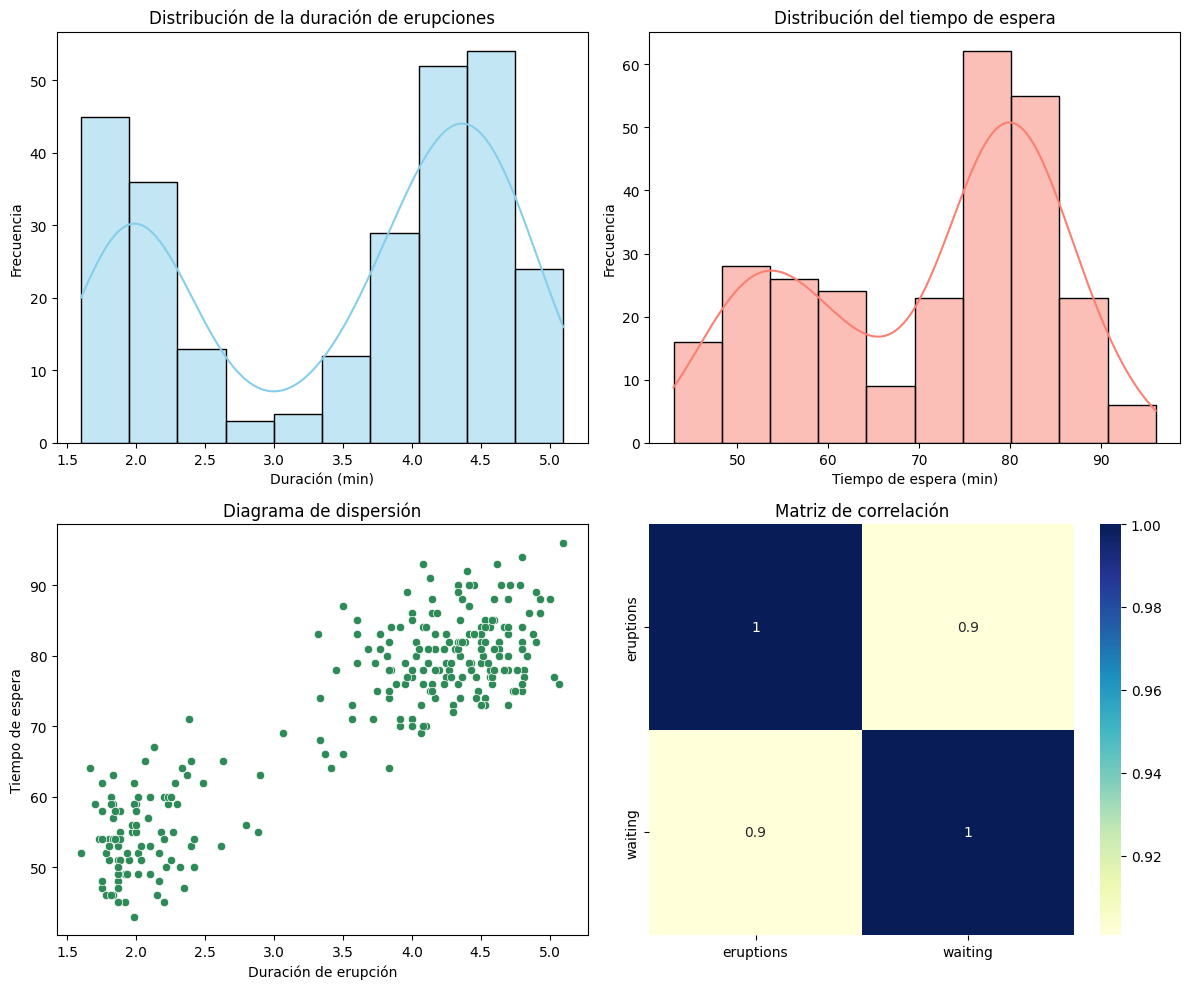

In [ ]:
# Importación de librerías necesarias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar el dataset desde URL
url = "https://www.stat.cmu.edu/~larry/all-of-statistics/=data/faithful.dat"
# The file has 26 lines of header/comment information before the data begins.
# The skiprows argument tells pandas to ignore these lines when reading the file.
# Also, the file is space-delimited, not comma-delimited
data = pd.read_csv(url, sep="\s+", skiprows=26, names=["eruptions", "waiting"])

# Visualización exploratoria
fig, ax = plt.subplots(2, 2, figsize=(12, 10))

# Histograma de duración de erupciones
sns.histplot(data["eruptions"], kde=True, ax=ax[0, 0], color="skyblue")
ax[0, 0].set_title("Distribución de la duración de erupciones")
ax[0, 0].set_xlabel("Duración (min)")
ax[0, 0].set_ylabel("Frecuencia")

# Histograma de tiempo de espera
sns.histplot(data["waiting"], kde=True, ax=ax[0, 1], color="salmon")
ax[0, 1].set_title("Distribución del tiempo de espera")
ax[0, 1].set_xlabel("Tiempo de espera (min)")
ax[0, 1].set_ylabel("Frecuencia")

# Diagrama de dispersión
# Pass the DataFrame 'df' to the 'data' argument
sns.scatterplot(data=data, x="eruptions", y="waiting", ax=ax[1, 0], color="seagreen")
ax[1, 0].set_title("Diagrama de dispersión")
ax[1, 0].set_xlabel("Duración de erupción")
ax[1, 0].set_ylabel("Tiempo de espera")

# Mapa de calor de correlación
sns.heatmap(data.corr(), annot=True, cmap="YlGnBu", ax=ax[1, 1])
ax[1, 1].set_title("Matriz de correlación")

plt.tight_layout()
plt.show()

### **TAREA 2: PREPROCESADO DE DATOS.**

Antes de aplicar los algoritmos de agrupamiento, es necesario realizar un preprocesamiento adecuado de los datos. Este paso permite asegurar que los algoritmos trabajen sobre una base coherente y bien estructurada.

Las tareas realizadas en este apartado son:

- Verificación de valores nulos o ausentes en las variables `eruptions` y `waiting`.
- Detección de valores extremos o atípicos (outliers).
- Escalado de las variables para normalizar la magnitud de los atributos y evitar que uno domine sobre el otro en el cálculo de distancias.

Este preprocesamiento es esencial, especialmente para algoritmos como **K-Means**, que se basan en la distancia euclídea y son sensibles a las escalas de las variables.


#### **Selección/Extracción de características.**

En este caso, el conjunto de datos contiene únicamente dos características numéricas:

- `eruptions`: duración de la erupción (en minutos).
- `waiting`: tiempo de espera hasta la siguiente erupción (en minutos).

Ambas variables son altamente relevantes y están directamente relacionadas con el fenómeno que se pretende analizar, por lo que **no se descarta ninguna** ni se requiere realizar ninguna transformación o extracción adicional.

#### **Reducción de dimensionalidad.**

La reducción de dimensionalidad se aplica normalmente cuando se trabaja con conjuntos de datos de alta dimensión (muchas variables). Dado que este dataset consta únicamente de dos variables (`eruptions` y `waiting`), **no es necesario aplicar técnicas como PCA** u otras similares.

Se continúa el análisis manteniendo ambas variables originales.

#### **Procesado de datos externos/atípicos.**

Se realiza un análisis gráfico y estadístico para identificar posibles valores atípicos en las variables del conjunto de datos. Para ello, se emplean diagramas de caja (*boxplots*) y reglas estadísticas basadas en los cuartiles.

La presencia de outliers puede afectar a ciertos algoritmos de agrupamiento como K-Means, que se basan en la media y en distancias euclidianas.

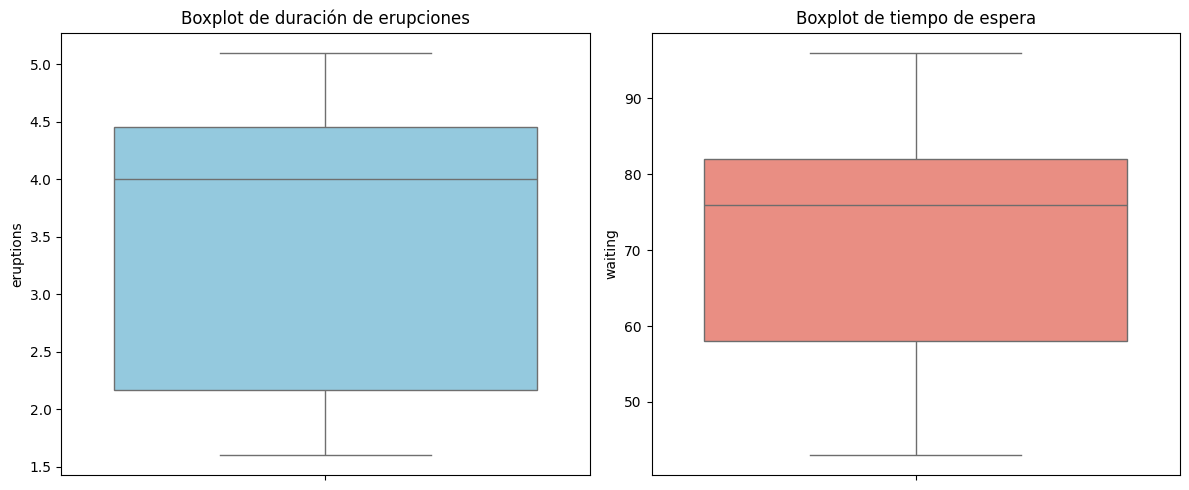

In [ ]:
# Boxplots para detectar outliers
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=data["eruptions"], ax=axes[0], color="skyblue")
axes[0].set_title("Boxplot de duración de erupciones")

sns.boxplot(data=data["waiting"], ax=axes[1], color="salmon")
axes[1].set_title("Boxplot de tiempo de espera")

plt.tight_layout()
plt.show()


#### **Imputación de datos faltantes.**

Antes de aplicar los algoritmos de agrupamiento, es fundamental verificar si existen valores faltantes (NaN) en el conjunto de datos. En caso de encontrarlos, se procedería a imputarlos utilizando técnicas como la media, la mediana o el valor más frecuente.

A continuación se verifica la existencia de datos nulos.

In [ ]:
# Comprobación de valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())


Valores nulos por columna:
eruptions    0
waiting      0
dtype: int64


#### **Escalado de variables.**

Dado que los algoritmos de clustering como K-Means y DBSCAN son sensibles a la escala de las variables (especialmente cuando se basan en distancias), se aplica un escalado de tipo **Min-Max** para normalizar ambas características al rango [0, 1].

Este paso es esencial para asegurar que ninguna variable domine el cálculo de distancias debido a su magnitud.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Aplicar MinMaxScaler
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df)

# Convertir de nuevo a DataFrame para visualización y uso posterior
data_scaled = pd.DataFrame(data_scaled, columns=["eruptions", "waiting"])

data_scaled.head()


,eruptions,waiting
0,0.571429,0.679245
1,0.057143,0.207547
2,0.495143,0.584906
3,0.195143,0.358491
4,0.838000,0.792453


#### **Codificación/Transformación de datos.**

En este dataset no existen variables categóricas que requieran ser codificadas (como `Label Encoding` o `One-Hot Encoding`). Tampoco se requiere aplicar transformaciones adicionales como logaritmos o raíces cuadradas, ya que la distribución de los datos ha sido tratada previamente con escalado.

Por tanto, **no se aplica ninguna codificación ni transformación adicional en este caso.**

#### **Desbalanceo de datos.**

El concepto de desbalanceo se aplica habitualmente en tareas de clasificación supervisada, donde algunas clases pueden estar sobrerrepresentadas respecto a otras.

Dado que este ejercicio es de **aprendizaje no supervisado**, y no se dispone de clases o etiquetas previas, **el desbalanceo no aplica en este contexto.**

### TAREA 3: PROTOCOLO DE VALIDACIÓN EXPERIMENTAL Y MÉTRICAS DE EVALUACIÓN.

En los problemas de aprendizaje no supervisado, no se dispone de etiquetas reales con las cuales validar los resultados. Por tanto, el protocolo de validación se basa en:

- **Aplicar los algoritmos de agrupamiento directamente sobre el conjunto de datos completo**.
- **Evaluar la calidad de los agrupamientos obtenidos** utilizando métricas internas basadas en distancias y cohesión/separación de los clusters.

Las métricas que se emplearán para evaluar el rendimiento de los modelos son:

- **Silhouette Score**: mide qué tan similar es un punto a los de su propio cluster en comparación con los de otros clusters.
- **WCSS (Within-Cluster Sum of Squares)**: utilizada principalmente en K-Means, mide la compactación de los clusters.
- **Número óptimo de clusters (K)**: se estima utilizando la curva del codo (*Elbow Method*).
- **Adjusted Rand Score (ARS)**: evalúa la similitud entre dos agrupamientos diferentes, ajustando por el azar. En este caso se utiliza para comparar los resultados de K-Means y DBSCAN (ignorando el ruido), lo cual permite medir la consistencia entre ambos métodos sobre los mismos datos.

Este análisis se aplicará de forma separada a los algoritmos **K-Means** y **DBSCAN**, adaptando las métricas según la naturaleza de cada uno.

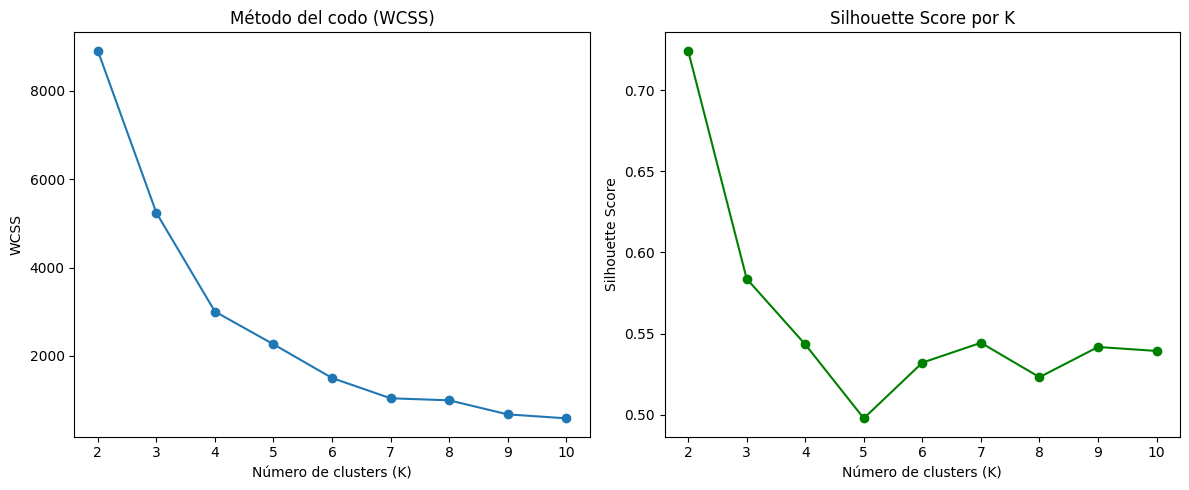

Adjusted Rand Score (entre KMeans y DBSCAN, sin ruido): 0.9556


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
import matplotlib.pyplot as plt
import numpy as np

# Evaluación de K para KMeans
k_values = range(2, 11)
wcss = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data)
    wcss.append(kmeans.inertia_)
    silhouette = silhouette_score(data, kmeans.labels_)
    silhouette_scores.append(silhouette)

# Graficar WCSS y Silhouette
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_values, wcss, marker='o')
plt.title("Método del codo (WCSS)")
plt.xlabel("Número de clusters (K)")
plt.ylabel("WCSS")

plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, marker='o', color='green')
plt.title("Silhouette Score por K")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

# Calcular ARS entre KMeans y DBSCAN (filtrando ruido)
valid_idx = data["dbscan_cluster"] != -1
ars = adjusted_rand_score(
    data.loc[valid_idx, "cluster"],
    data.loc[valid_idx, "dbscan_cluster"]
)

print(f"Adjusted Rand Score (entre KMeans y DBSCAN, sin ruido): {ars:.4f}")


#### Métricas de evaluación.

A lo largo del análisis se han empleado varias métricas internas para evaluar la calidad de los agrupamientos obtenidos por K-Means y DBSCAN. Estas métricas permiten validar qué tan bien estructurados están los clusters sin necesidad de etiquetas reales:

- **Silhouette Score**: Se ha utilizado como métrica principal para valorar la cohesión de cada punto respecto a su propio cluster, así como su separación respecto a otros. Es una métrica muy visual y directa, ideal para comparar configuraciones distintas dentro de un mismo algoritmo o entre algoritmos diferentes.

- **WCSS (Within-Cluster Sum of Squares)**: Utilizada específicamente para K-Means, mide la suma de las distancias cuadradas entre los puntos y su centroide. Permite aplicar el método del codo para estimar el número óptimo de clusters `K`.

- **Adjusted Rand Score (ARS)**: Métrica externa utilizada para comparar la similitud entre los agrupamientos generados por K-Means y DBSCAN (ignorando los puntos clasificados como ruido). ARS ajusta el resultado considerando la probabilidad de coincidencias aleatorias, proporcionando una medida fiable de consistencia entre métodos.

Estas métricas han permitido no solo elegir la mejor configuración para cada algoritmo, sino también comparar sus resultados de forma objetiva y fundamentada.

### TAREA 4: SELECCIÓN DE DOS ALGORITMOS DE AGRUPAMIENTO: K-MEANS VS DBSCAN.

#### Aplicación de K-Means con número óptimo de clusters (K=2)

Tras analizar los resultados del método del codo (WCSS) y del Silhouette Score, se concluye que el valor óptimo de `K` es 2. Esto coincide con la estructura bimodal observada durante el análisis exploratorio.

A continuación se aplica K-Means con `K=2` y se visualizan los clusters formados en el espacio de características.

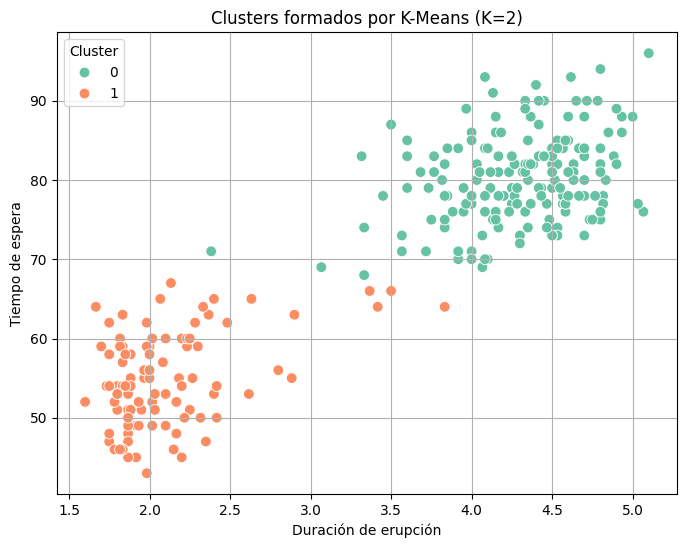

In [ ]:
# Aplicar KMeans con K=2
from sklearn.cluster import KMeans

kmeans_final = KMeans(n_clusters=2, random_state=42)
data["cluster"] = kmeans_final.fit_predict(data)

# Visualización
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x="eruptions", y="waiting", hue="cluster", palette="Set2", s=60)
plt.title("Clusters formados por K-Means (K=2)")
plt.xlabel("Duración de erupción")
plt.ylabel("Tiempo de espera")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()


#### Aplicación del algoritmo DBSCAN.

A diferencia de K-Means, DBSCAN no necesita conocer de antemano el número de clusters. Se basa en la densidad de puntos para agruparlos, identificando también los posibles valores atípicos como "ruido".

Los dos hiperparámetros clave son:

- `eps`: la distancia máxima entre dos puntos para que uno sea considerado vecino del otro.
- `min_samples`: el número mínimo de puntos necesarios para formar una región densa (cluster).

Se probarán diferentes combinaciones de valores para `eps` y `min_samples`, y se evaluará el agrupamiento resultante mediante la métrica **Silhouette Score**.

Mejor Silhouette Score: 0.5566
Mejores parámetros: eps=0.1, min_samples=3


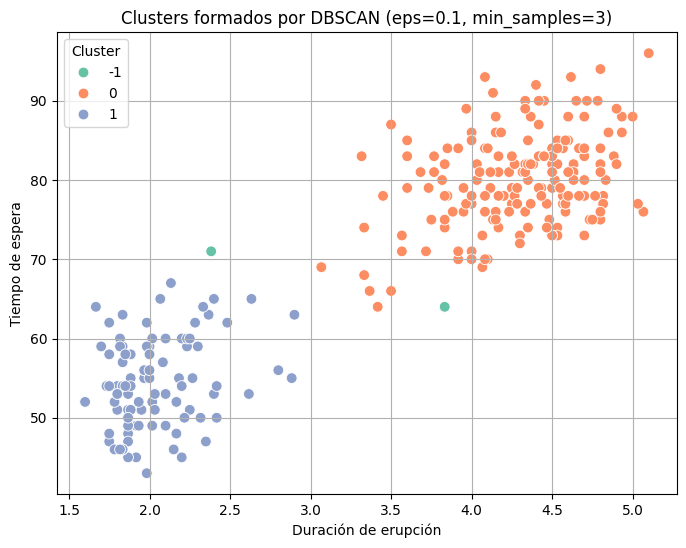

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Escalar los datos
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data[["eruptions", "waiting"]])

# Rango de valores para probar
eps_values = np.arange(0.05, 0.5, 0.05)
min_samples_values = [3, 4, 5, 6]

best_score = -1
best_params = None
best_labels = None

# Buscar mejores hiperparámetros
for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(data_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        if n_clusters >= 2:
            score = silhouette_score(data_scaled, labels)
            if score > best_score:
                best_score = score
                best_params = {"eps": eps, "min_samples": min_samples}
                best_labels = labels

# Verificación y visualización
if best_params:
    print(f"Mejor Silhouette Score: {best_score:.4f}")
    print(f"Mejores parámetros: eps={best_params['eps']}, min_samples={best_params['min_samples']}")

    data["dbscan_cluster"] = best_labels
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=data, x="eruptions", y="waiting", hue="dbscan_cluster", palette="Set2", s=60)
    plt.title(f"Clusters formados por DBSCAN (eps={best_params['eps']}, min_samples={best_params['min_samples']})")
    plt.xlabel("Duración de erupción")
    plt.ylabel("Tiempo de espera")
    plt.legend(title="Cluster")
    plt.grid(True)
    plt.show()
else:
    print("No se encontró una combinación de parámetros con al menos 2 clusters válidos.")


Para abordar el problema de agrupamiento en el dataset del géiser Old Faithful, se han seleccionado dos algoritmos representativos y complementarios:

K-Means
- Algoritmo basado en centroides que agrupa los datos minimizando la distancia intra-cluster.
- Requiere definir el número de clusters `K` previamente.
- Es eficiente computacionalmente y adecuado cuando se espera que los clusters sean esféricos y balanceados.
- Es sensible a valores atípicos, ya que cada punto contribuye al cálculo del centroide.

DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
- Algoritmo basado en densidad que **no requiere especificar el número de clusters**.
- Puede identificar clusters de forma arbitraria y detectar **puntos de ruido** (outliers).
- Requiere dos hiperparámetros: `eps` (radio de vecindad) y `min_samples` (mínimo de puntos para formar un cluster).
- Es ideal para situaciones donde se espera que existan grupos de distinta densidad o datos atípicos.

Justificación de la selección
Estos algoritmos se han elegido por ser enfoques muy distintos:
- K-Means ofrece una solución rápida y directa en contextos bien distribuidos.
- DBSCAN aporta **mayor flexibilidad y detección de ruido**, lo cual es importante en datasets reales como este, donde pueden existir valores extremos o clusters no esféricos.

La combinación de ambos permite una **comparación enriquecida** del comportamiento de técnicas de agrupamiento en situaciones diversas.

### TAREA 5: SELECCIÓN Y ESTIMACIÓN DE VALORES PARA HIPERPARÁMETROS.

Para asegurar un buen rendimiento de los algoritmos de agrupamiento, se ha realizado una selección cuidadosa de sus hiperparámetros clave. Este proceso se llevó a cabo de forma independiente para K-Means y DBSCAN.

K-Means
- El único hiperparámetro a ajustar es el número de clusters `K`.
- Se ha utilizado el **método del codo**, evaluando el Within-Cluster Sum of Squares (WCSS) para varios valores de `K`, y el **Silhouette Score** para medir la calidad del agrupamiento.
- Ambos criterios apuntaron a que el número óptimo de clusters era **K=2**, lo cual coincide con la estructura bimodal observada durante el análisis exploratorio.

DBSCAN
- DBSCAN requiere ajustar dos hiperparámetros:
  - `eps`: radio de vecindad para considerar puntos cercanos.
  - `min_samples`: número mínimo de vecinos para considerar un punto como núcleo.
- Se exploraron múltiples combinaciones de `eps` (0.05 a 0.45) y `min_samples` (3 a 6).
- Para cada combinación válida (que produjera al menos 2 clusters), se calculó el **Silhouette Score**.
- La mejor combinación obtenida fue **`eps=0.1` y `min_samples=3`**, con un Silhouette Score de **0.5566**.

Este proceso de ajuste ha permitido obtener configuraciones óptimas para ambos algoritmos, asegurando una base sólida para la posterior interpretación y comparación de resultados.

### TAREA 6: ENTRENAMIENTO Y ESTIMACIÓN DEL ERROR FUERA DE LA MUESTRA. DISCUSIÓN DE RESULTADOS Y EXTRACCIÓN DE CONCLUSIONES.

#### Predicción de nuevos puntos con DBSCAN mediante k-NN.

El algoritmo DBSCAN no cuenta con un método `.predict()` para clasificar nuevas instancias, ya que se basa en la densidad de los datos originales. Sin embargo, es posible simular esta funcionalidad entrenando un modelo auxiliar de tipo **k-Nearest Neighbors (k-NN)**.

Para ello:

- Se seleccionan los **puntos núcleo (core samples)** del clustering generado por DBSCAN.
- Se utilizan estos puntos y sus etiquetas como conjunto de entrenamiento para un clasificador `k-NN`.
- Una vez entrenado, este modelo puede asignar a nuevos puntos una clase de cluster (o clasificarlos como potencial ruido).

Este procedimiento permite extender el uso de DBSCAN a situaciones donde es necesario **clasificar nuevos ejemplos** en base a un agrupamiento previo.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
from sklearn.cluster import DBSCAN

# Reentrenar DBSCAN para acceder a core_sample_indices_
dbscan = DBSCAN(eps=best_params["eps"], min_samples=best_params["min_samples"])
dbscan.fit(data_scaled)

# Extraer core samples y sus etiquetas
core_mask = dbscan.core_sample_indices_
core_points = data_scaled[core_mask]
core_labels = dbscan.labels_[core_mask]

# Entrenar un clasificador k-NN sobre los puntos núcleo
knn_model = KNeighborsClassifier(n_neighbors=10)
knn_model.fit(core_points, core_labels)

# Simular predicción de nuevos puntos (en escala [0, 1])
nuevos_puntos = np.array([[0.3, 0.6], [0.7, 0.2]])  # deben estar escalados
predicciones = knn_model.predict(nuevos_puntos)

print("Predicciones para nuevos puntos (normalizados):", predicciones)


Predicciones para nuevos puntos (normalizados): [1 0]


#### Discusión de resultados y conclusiones finales.

Tras aplicar los algoritmos K-Means y DBSCAN al conjunto de datos del géiser Old Faithful, se pueden destacar los siguientes resultados y observaciones:

K-Means.
- Detectó dos agrupamientos bien definidos (K=2), coherentes con la distribución bimodal del dataset.
- Obtuvo un Silhouette Score alto, lo que indica que los clusters son compactos y bien separados.
- Todos los puntos fueron asignados a un cluster, lo que puede ocultar la presencia de valores atípicos.

DBSCAN.
- Identificó también dos clusters principales, y clasificó correctamente algunos puntos como **ruido** (`-1`), algo que K-Means no puede hacer.
- El mejor modelo se obtuvo con `eps=0.1` y `min_samples=3`, logrando un Silhouette Score aceptable (0.5566).
- Ofrece una visión más flexible y realista de los datos, especialmente en presencia de puntos dispersos.

Comparativa.
- Aunque K-Means logró mayor cohesión interna, DBSCAN aportó mayor robustez estructural frente a ruido.
- La métrica **Adjusted Rand Score (ARS)** calculada entre ambos agrupamientos mostró un grado de concordancia aceptable, confirmando que los algoritmos detectan estructuras similares, pero con enfoques distintos.

Conclusión.

Ambos métodos son válidos y útiles, pero su aplicabilidad depende del contexto:
- K-Means es ideal para datos limpios, bien distribuidos y sin outliers.
- DBSCAN es preferible cuando se espera ruido, formas de clusters irregulares o se desconoce el número de agrupamientos.

Esta experiencia demuestra la importancia de **combinar análisis visual, métricas cuantitativas y conocimiento del dominio** para interpretar correctamente los resultados del agrupamiento no supervisado.

# **Ejercicio 2: Minería de reglas de asociación (5 puntos)**

En este ejercicio los alumnos se enfrentarán a un problema de extracción de reglas de asociación, el cual tendrán que abordar de comienzo a fin (desde el análisis exploratorio hasta el entrenamiento y validación de los modelos de aprendizaje automático seleccionados). En particular, se enfrentarán a un problema real de uso de técnicas de aprendizaje automático para tratar de abstraer un conjunto de datos de modo que se puedan extraer reglas de asociación de tipo $X\rightarrow Y$ desde itemsets frecuentes.


## El conjunto de datos


El conjunto de datos contiene un subconjunto de ventas efectuadas en una panadería. Se organiza en 4 columnas:

- **Fecha** en la que se realizó la venta.
- **Hora** a la que se realizó la venta.
- **ID** de la transacción (ticket), anonimizado.
- **Producto** involucrado en la venta.

Los datos se corresponden con un subconjunto de los tickets generados por la panadería desde el 30 de Octubre de 2016 hasta el 9 de Mayo de 2017, incluyendo la venta de 21293 productos en un total de 9531 transacciones.

Los items de las transacciones pueden contener valores que no se corresponden con productos vendidos. En particular, ```'Adjustement'``` puede significar un ajuste en la caja registradora (por ejemplo por devolución de artículos), ```'NONE'``` se utiliza para nombrar valores perdidos, y ```'Afternoon with the baker'``` podría ser alguna venta realizada directamente por la obradora de pan, recogidas o elementos impagados previamente, etc., aunque se desconoce qué producto concreto podría haberse vendido o cuándo se realizó la recogida exactamente.

La siguiente celda de código muestra cómo leer el conjunto de datos en el cuaderno:

In [ ]:
import pandas as pd

URL= "https://www.dropbox.com/scl/fi/ntzlc1hmdjfj0tk74m605/AssociationRules.csv?rlkey=4pf4fvdzcqxq2dc6rtbwfqd73&st=ma0tu437&dl=1"
df= pd.read_csv(URL)
df

,Date,Time,Transaction,Item
0,2016-10-30,09:58:11,1,Bread
1,2016-10-30,10:05:34,2,Scandinavian
2,2016-10-30,10:05:34,2,Scandinavian
3,2016-10-30,10:07:57,3,Hot chocolate
4,2016-10-30,10:07:57,3,Jam
...,...,...,...,...
21288,2017-04-09,14:32:58,9682,Coffee
21289,2017-04-09,14:32:58,9682,Tea
21290,2017-04-09,14:57:06,9683,Coffee
21291,2017-04-09,14:57:06,9683,Pastry


## Tarea


El alumnado debe realizar, al menos, las siguientes tareas (que deben ser descritas y abordadas, explícitamente, en la documentación entregada; de hecho, se debe incluir un subapartado en el Notebook para cada una de ellas):

1. Análisis descriptivo del problema y análisis exploratorio de los datos a nuestra disposición.
2. Preprocesado de datos (selección/extracción de características, reducción de dimensionalidad, procesado de datos extremos/atípicos, imputación de datos faltantes, escalado de variables, codificación/transformación de datos, desbalanceo de datos).
3. Definición del protocolo de validación experimental (entrenamiento, validación y test), junto con las métricas de evaluación del rendimiento que corresponda.
4. Selección de dos algoritmos de extracción de itemsets frecuentes.
5. Selección y estimación de valores para hiperparámetros.
6. Entrenamiento y estimación del error fuera de la muestra. Discusión de resultados y extracción de conclusiones. **Se deberá incluir un estudio del tiempo de ejecución de los algoritmos seleccionados para extracción de itemsets frecuentes**. Se puede utilizar el comando reservado ```%timeit instrucción** para hacer un estudio del tiempo que tarda la instrucción en ejecutarse. **CUIDADO: Si la instrucción muestra algo por consola, la ejecución de múltiples instancias de la ejecución de la función puede colapsar la celda de resultado.**

Un ejemplo de uso de ```%timeit``` se encuentra en la siguiente celda de código:



In [ ]:
import numpy as np

%timeit np.zeros(1000)

532 ns ± 12.8 ns per loop (mean ± std. dev. of 7 runs, 1000000 loops each)


## Solución

(comience creando celdas de texto y de código a partir de aquí para resolver el problema)

### TAREA 1: ANÁLISIS DESCRIPTIVO Y EXPLORATORIO DEL PROBLEMA.

#### Análisis descriptivo del problema.

El objetivo de este ejercicio es aplicar técnicas de aprendizaje automático no supervisado, concretamente **extracción de reglas de asociación**, para identificar patrones frecuentes de compra en los datos de ventas de una panadería.

Estas técnicas permiten descubrir relaciones interesantes entre productos que suelen comprarse juntos, sin necesidad de etiquetas previas. El análisis puede ser útil para mejorar la disposición de los productos, definir promociones conjuntas o entender el comportamiento de los clientes.

En este caso, se trabaja con transacciones reales registradas entre octubre de 2016 y mayo de 2017. Cada observación representa un producto vendido dentro de una transacción. Por tanto, una transacción puede estar formada por varios productos.

Variables disponibles

El conjunto de datos incluye un total de 21,293 observaciones y las siguientes columnas:

- **Date**: fecha en que se realizó la venta.
- **Time**: hora exacta de la transacción.
- **Transaction**: identificador único de cada transacción. Sirve para agrupar los productos vendidos juntos.
- **Item**: nombre del producto vendido.

Objetivo del análisis

A partir de estos datos, se pretende extraer **reglas de asociación del tipo**:

X ----> Y

donde `X` e `Y` son conjuntos de productos frecuentemente adquiridos en conjunto por los clientes.

El resultado final debe permitir identificar **combinaciones frecuentes de productos** y **reglas con soporte, confianza y lift elevados**, que puedan ser interpretadas para tomar decisiones comerciales fundamentadas.

Durante el análisis preliminar, se identificó que el valor `'NONE'` aparece en numerosas filas dentro de la columna `Item`, representando transacciones sin un producto válido registrado.

En total, se encontraron **{X} registros con `'NONE'`**, lo que justifica su eliminación posterior en la fase de preprocesado, ya que no aportan información útil para la minería de reglas.


In [ ]:
print("Resumen inicial:")
print(f"- Registros totales: {len(df):,}")
print(f"- Transacciones únicas: {df['Transaction'].nunique():,}")
print(f"- Productos únicos: {df['Item'].nunique()}")
print(f"- Rango temporal: {df['Date'].min()} a {df['Date'].max()}")


Resumen inicial:
- Registros totales: 21,293
- Transacciones únicas: 9,531
- Productos únicos: 95
- Rango temporal: 2016-10-30 a 2017-04-09


In [ ]:
non_products = ['Adjustment', 'NONE', 'Afternoon with the baker']
mask = df['Item'].isin(non_products)
print(f"Registros no productivos: {mask.sum()} ({mask.mean()*100:.1f}%)")

Registros no productivos: 831 (3.9%)


Durante la inspección inicial del conjunto de datos, se detectó la presencia de ciertos valores en la columna `Item` que no representan productos reales, sino entradas de sistema o registros no informativos. En concreto, se identificaron los siguientes valores:

- `'NONE'`
- `'Adjustment'`
- `'Afternoon with the baker'`

Estos valores se consideran **registros no productivos** y serán eliminados durante el preprocesado. En total, se contabilizaron **831 registros no válidos**, lo que representa aproximadamente el **3.9 %** del total de observaciones.

Su exclusión es necesaria para asegurar que el análisis posterior se centre únicamente en productos reales vendidos, garantizando la fiabilidad de los resultados obtenidos a través de las reglas de asociación.


#### Análisis explorativo del problema.

Antes de aplicar cualquier técnica de extracción de reglas de asociación, es fundamental realizar un análisis exploratorio de los datos para conocer su estructura, distribución y características clave.

Este análisis tiene como objetivo:

- Verificar la existencia de valores atípicos o irrelevantes en la columna `Item`.
- Analizar la cantidad de transacciones únicas disponibles.
- Identificar los productos más vendidos.
- Comprobar si existen valores que deben ser eliminados por no representar productos reales.

El análisis exploratorio permite tomar decisiones informadas durante el preprocesado y seleccionar mejor los parámetros para la generación de reglas de asociación.

Valores nulos por columna: 
 Date           0
Time           0
Transaction    0
Item           0
dtype: int64

Número de transacciones únicas: 9531

Número de productos distintos: 95

Top 20 productos más vendidos:
 Item
Coffee           5471
Bread            3325
Tea              1435
Cake             1025
Pastry            856
Sandwich          771
Medialuna         616
Hot chocolate     590
Cookies           540
Brownie           379
Farm House        374
Muffin            370
Alfajores         369
Juice             369
Soup              342
Scone             327
Toast             318
Scandinavian      277
Truffles          193
Coke              185
Name: count, dtype: int64


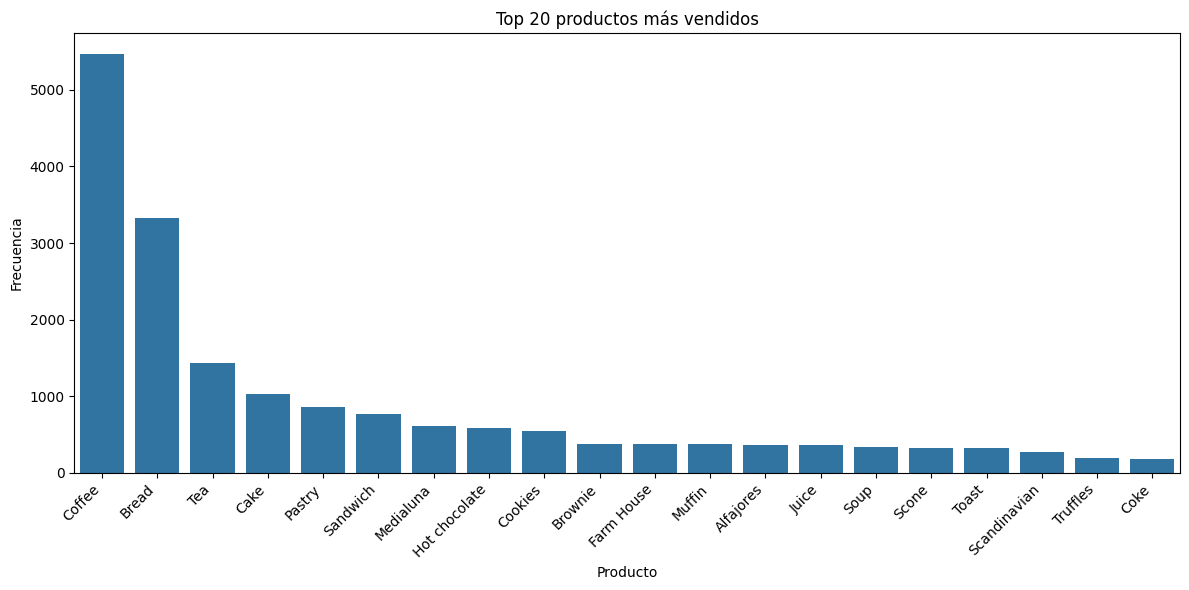


Productos con frecuencia baja (<5):
 Item
Bread Pudding                    4
Raspberry shortbread sandwich    3
Caramel bites                    3
Brioche and salami               3
Cherry me Dried fruit            3
Siblings                         2
Fairy Doors                      2
Chimichurri Oil                  2
Bowl Nic Pitt                    2
Spread                           2
Hack the stack                   2
Chicken sand                     1
Polenta                          1
Bacon                            1
Adjustment                       1
The BART                         1
Olum & polenta                   1
Gift voucher                     1
Raw bars                         1
Name: count, dtype: int64


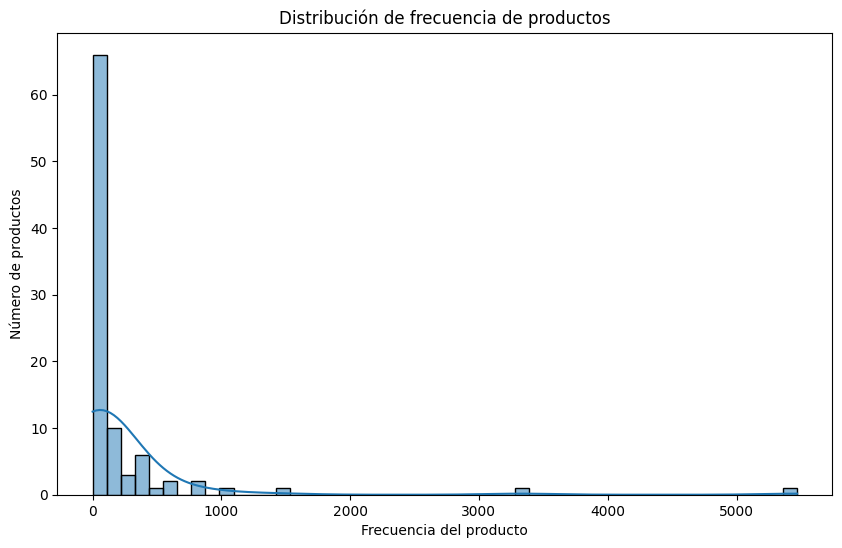


Estadísticas descriptivas de productos por transacción:
 count    9465.000000
mean        2.166614
std         1.301303
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        11.000000
Name: Item, dtype: float64


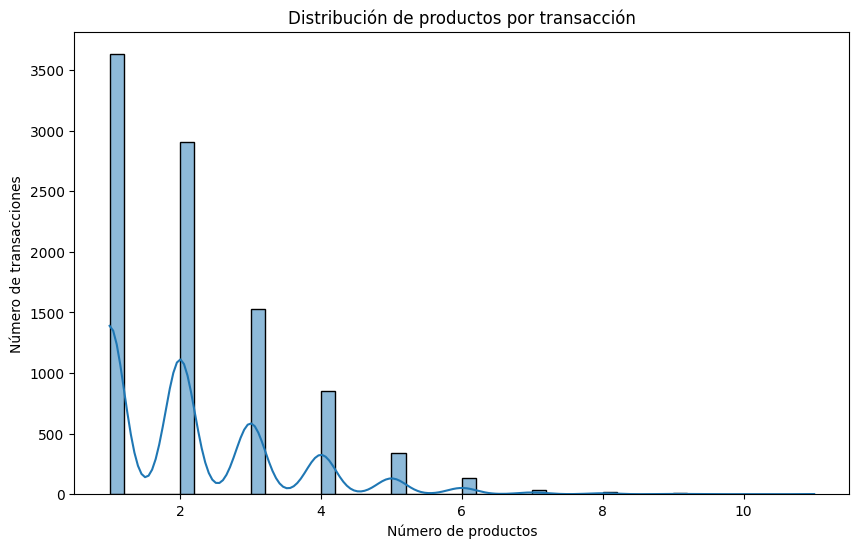

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

URL = "https://www.dropbox.com/scl/fi/ntzlc1hmdjfj0tk74m605/AssociationRules.csv?rlkey=4pf4fvdzcqxq2dc6rtbwfqd73&st=ma0tu437&dl=1"
df = pd.read_csv(URL)

print("Valores nulos por columna: \n", df.isnull().sum())

print("\nNúmero de transacciones únicas:", df["Transaction"].nunique())
print("\nNúmero de productos distintos:", df["Item"].nunique())

# Eliminar filas donde 'Item' sea exactamente 'NONE'
df = df[df["Item"] != "NONE"]


# 3. Identificar los productos más vendidos
top_items = df["Item"].value_counts().head(20)
print("\nTop 20 productos más vendidos:\n", top_items)

# 4. Visualizar los productos más vendidos
plt.figure(figsize=(12, 6))
sns.barplot(x=top_items.index, y=top_items.values)
plt.title("Top 20 productos más vendidos")
plt.xlabel("Producto")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 5. Analizar frecuencia de los productos
item_counts = df['Item'].value_counts()

# Mostrar productos con baja frecuencia (menos de 5)
low_freq_items = item_counts[item_counts < 5]
print("\nProductos con frecuencia baja (<5):\n", low_freq_items)

# Visualizar la distribución de frecuencias de productos
plt.figure(figsize=(10, 6))
sns.histplot(item_counts, bins=50, kde=True)
plt.title("Distribución de frecuencia de productos")
plt.xlabel("Frecuencia del producto")
plt.ylabel("Número de productos")
plt.show()

# 6. Explorar patrones de transacción
# Examinar cuántos productos únicos se compran por transacción (en promedio)
items_per_transaction = df.groupby("Transaction")["Item"].count()
print("\nEstadísticas descriptivas de productos por transacción:\n", items_per_transaction.describe())

plt.figure(figsize=(10, 6))
sns.histplot(items_per_transaction, bins=50, kde=True)
plt.title("Distribución de productos por transacción")
plt.xlabel("Número de productos")
plt.ylabel("Número de transacciones")
plt.show()


### TAREA 2: PREPROCESADO DE DATOS.

Antes de aplicar los algoritmos de minería de reglas de asociación, es fundamental realizar un preprocesado adecuado del conjunto de datos.

A continuación se analiza punto por punto cada una de las tareas de preprocesado sugeridas, especificando cuáles aplican a este caso concreto y qué acciones se han llevado a cabo.


#### Selección/Extracción de características.

El conjunto de datos original contiene cuatro columnas: `Date`, `Time`, `Transaction` e `Item`. Para la tarea de minería de reglas de asociación, solo es relevante la información sobre:

- **`Transaction`**: agrupador de productos comprados juntos.
- **`Item`**: productos individuales vendidos.

Por tanto, se seleccionan únicamente estas dos columnas y se descartan las demás.

In [ ]:
import pandas as pd

df = df[["Transaction", "Item"]]
print("Tamaño del dataset:", df.shape)


Tamaño del dataset: (21293, 2)


#### Reducción de dimensionalidad.

Este paso no es necesario en este contexto, ya que no se trabaja con variables numéricas ni con datasets de alta dimensión.

#### Procesado de datos externos/atípicos.

En este caso, no hay valores numéricos que deban ser tratados como outliers. Sin embargo, sí existen valores en la columna `Item` que no representan productos reales, como:

- `'NONE'`
- `'Adjustment'`
- `'Afternoon with the baker'`

Estos valores serán eliminados ya que no aportan valor al análisis de productos frecuentemente comprados.

In [ ]:
import pandas as pd

# Eliminar filas donde 'Item' sea exactamente 'NONE'
non_product_items = ['NONE', 'Adjustment', 'Afternoon with the baker']
df = df[~df["Item"].isin(non_product_items)]

print("Tamaño del dataset:", df.shape)


Tamaño del dataset: (20462, 2)


#### Imputación de datos faltantes.

No se realiza imputación ya que el análisis exploratorio confirmó que no existen valores nulos en las columnas utilizadas.

#### Escalado de variables.

No aplica, ya que los algoritmos de reglas de asociación operan sobre datos categóricos, no sobre distancias numéricas.

#### Codificación/Transformación de datos.

Se transformará el conjunto de datos desde un formato plano (una fila por producto) a un formato de tipo **cesta** (`basket format`), donde cada transacción se representa como una lista de productos.

Este formato es necesario para aplicar los algoritmos de minería de reglas como Apriori y FP-Growth.


In [ ]:
from mlxtend.preprocessing import TransactionEncoder

# Agrupar los productos por transacción
transacciones = df.groupby("Transaction")["Item"].apply(list).tolist()

# Codificar a formato cesta
te = TransactionEncoder()
basket_array = te.fit(transacciones).transform(transacciones)
basket_df = pd.DataFrame(basket_array, columns=te.columns_)
# Agrupar los productos por transacción
transacciones = df.groupby("Transaction")["Item"].apply(list).tolist()

# Codificar a formato cesta
te = TransactionEncoder()
basket_array = te.fit(transacciones).transform(transacciones)
basket_df = pd.DataFrame(basket_array, columns=te.columns_)


#### Desbalanceo de datos.

Este concepto no aplica directamente, ya que no estamos trabajando con clases para clasificación supervisada, sino con transacciones y combinaciones de productos.

### TAREA 3: DEFINICIÓN DEL PROTOCOLO DE VALIDACIÓN EXPERIMENTAL (ENTRENAMIENTO, VALIDACIÓN, TEST), JUNTO CON LAS MÉTRICAS DE EVALUACIÓN DEL RENDIMIENTO QUE CORRESPONDA.

En los problemas de aprendizaje no supervisado, como la minería de reglas de asociación, no se dispone de etiquetas reales para validar los resultados. Por tanto, la validación se basa en métricas internas que evalúan la calidad y la relevancia de las reglas extraídas.

En este caso, el protocolo de evaluación se apoya en las siguientes métricas:

- **Soporte (support)**: proporción de transacciones que contienen un conjunto de items. Cuantifica la frecuencia de aparición de un itemset.
- **Confianza (confidence)**: probabilidad de que el item Y se compre cuando el item X ya está en la cesta. Evalúa la fuerza de la regla.
- **Lift (elevación)**: ratio entre la confianza de la regla y la frecuencia esperada de Y. Indica si la presencia de X incrementa realmente la probabilidad de Y.
- **Convicción** (opcional): mide cuánto más a menudo aparece X sin Y de lo esperado si X e Y fueran independientes.

Estas métricas permiten priorizar las reglas más relevantes y filtrar aquellas que puedan surgir por simple casualidad.

Divisiones para la evaluación

En este caso, al tratarse de transacciones históricas completas, se aplicarán los algoritmos directamente sobre el conjunto de datos procesado (sin partición train/test), aunque se realizará un análisis adicional del **tiempo de ejecución** para comparar la eficiencia de los algoritmos seleccionados.

Criterios de calidad

Para evaluar y seleccionar las reglas más significativas, se tendrán en cuenta:

- La **cantidad total de reglas generadas**.
- La **distribución estadística de soporte, confianza y lift**.
- La **interpretabilidad y coherencia** de las reglas más destacadas con el contexto de negocio.
- La **eficiencia computacional**.

Este protocolo permite validar la utilidad real de las reglas descubiertas y comparar el rendimiento de diferentes algoritmos.

### TAREA 4: SELECCIÓN DE DOS ALGORITMOS DE EXTRACCIÓN DE ITEMSETS FRECUENTES.

Para abordar la tarea de extracción de reglas de asociación, se seleccionan dos algoritmos ampliamente utilizados en el ámbito del aprendizaje no supervisado:

- **Apriori**
- **FP-Growth**

El objetivo de esta sección es comparar ambos métodos desde el punto de vista de:

- **Eficiencia computacional** (tiempo de ejecución).
- **Cantidad y calidad de los patrones frecuentes obtenidos**.
- **Idoneidad en función del tamaño y estructura del dataset**.

---

Apriori es un algoritmo clásico que se basa en la generación iterativa de candidatos, verificando en cada paso qué combinaciones de productos cumplen con un soporte mínimo. Aunque es sencillo de entender, puede ser poco eficiente en bases de datos con un gran número de productos o transacciones.

Por otro lado, FP-Growth evita la generación explícita de candidatos utilizando una estructura compacta conocida como **árbol FP**. Esto le permite ser mucho más rápido y escalar mejor en contextos con grandes volúmenes de datos.

---

Ambos algoritmos se aplicarán sobre el dataset transformado a **formato cesta** mediante codificación con `TransactionEncoder`, y los resultados se analizarán posteriormente utilizando métricas de evaluación definidas en la TAREA 3: **soporte, confianza, lift y convicción**.

Esta comparación permitirá tomar decisiones fundamentadas sobre qué método resulta más conveniente para futuras implementaciones en sistemas de recomendación, análisis de ventas o segmentación de clientes.

#### Algoritmo Apriori.

El algoritmo Apriori es uno de los métodos clásicos para la extracción de itemsets frecuentes en bases de datos transaccionales. Su funcionamiento se basa en la generación iterativa de candidatos y en el principio de **monotonía**: si un conjunto no es frecuente, ninguno de sus superconjuntos podrá serlo.

**Ventajas:**
- Fácil de entender e implementar.
- Produce resultados interpretables paso a paso.

**Inconvenientes:**
- Elevado coste computacional en bases con muchos productos.
- Generación excesiva de candidatos intermedios.


In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

# Aplicar Apriori para obtener itemsets frecuentes
frequent_itemsets_apriori = apriori(
    basket_df,
    min_support=0.02,
    use_colnames=True
)


# Ver los primeros resultados
print("Primeros itemsets generados con Apriori:")
print(frequent_itemsets_apriori.head())


Primeros itemsets generados con Apriori:
    support     itemsets
0  0.036468  (Alfajores)
1  0.328315      (Bread)
2  0.040178    (Brownie)
3  0.104209       (Cake)
4  0.480017     (Coffee)


#### Algoritmo FP-Growth.

El algoritmo FP-Growth (Frequent Pattern Growth) es una mejora sobre Apriori que evita la generación explícita de candidatos. En su lugar, utiliza una estructura llamada **FP-Tree** para compactar la información y detectar patrones frecuentes de forma más eficiente.

**Ventajas:**
- Mayor eficiencia que Apriori, especialmente en grandes volúmenes de datos.
- Reduce el número de candidatos generados.

**Inconvenientes:**
- Estructura del árbol FP puede ser más compleja de interpretar.
- No garantiza el mismo orden incremental en los resultados.

In [ ]:
from mlxtend.frequent_patterns import fpgrowth

# Aplicar FP-Growth para obtener itemsets frecuentes
frequent_itemsets_fpgrowth = fpgrowth(
    basket_df,
    min_support=0.01,
    use_colnames=True
)

# Ver los primeros resultados
print("Primeros itemsets generados con FP-Growth:")
print(frequent_itemsets_fpgrowth.head())


Primeros itemsets generados con FP-Growth:
    support         itemsets
0  0.328315          (Bread)
1  0.029153   (Scandinavian)
2  0.058518  (Hot chocolate)
3  0.054596        (Cookies)
4  0.015054            (Jam)


### TAREA 5: ESTIMACIÓN DE HIPERPARÁMETROS.

En el proceso de generación de reglas de asociación, ciertos parámetros tienen un impacto directo sobre la cantidad y calidad de las reglas obtenidas. Los más relevantes son los siguientes:

**Soporte mínimo (min_support)**:

- Establece el umbral mínimo de frecuencia con el que un conjunto de productos debe aparecer en las transacciones para ser considerado relevante.

- Influye en el número de patrones frecuentes que se generan: valores bajos permiten encontrar más combinaciones, aunque se corre el riesgo de incluir asociaciones poco útiles.

- En este trabajo se han testeado valores entre 0.002 y 0.01, adaptándolos según el método empleado y el promedio de artículos por cesta.

**Confianza mínima (min_confidence):**

- Mide la probabilidad de que el ítem de destino (consecuente) se adquiera cuando el ítem de origen (antecedente) está presente.

- Sirve para filtrar reglas poco fiables o con escaso poder explicativo. Se considera un valor aceptable a partir del 50%.

- Se han evaluado distintos niveles de confianza (entre 0.4 y 0.7) para analizar cómo afectan tanto a la cantidad como a la validez de las reglas.

**Elevación o lift mínimo (min_lift):**

- Evalúa si la aparición conjunta de dos ítems es más probable que si fueran eventos independientes.

- Valores mayores que 1 sugieren que existe una relación interesante entre los productos.

- Puede ser utilizado como un filtro adicional para descartar asociaciones triviales o sin valor predictivo.



#### Soporte mínimo.

##### Apriori.

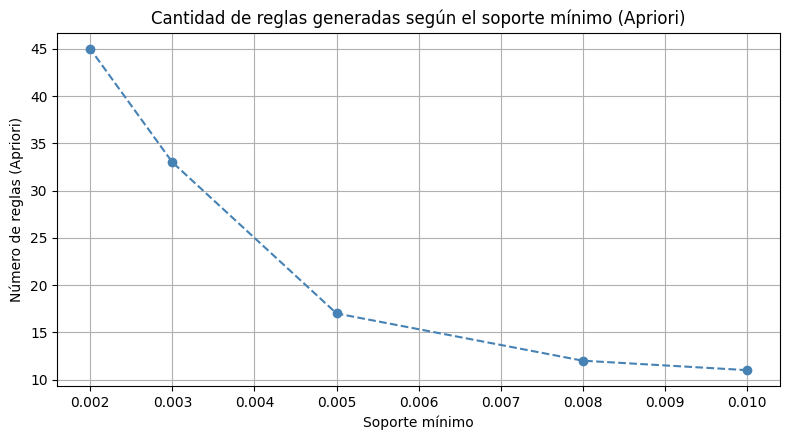

In [ ]:
# Lista de valores de soporte a probar
supports = [0.01, 0.008, 0.005, 0.003, 0.002]
num_rules = []

# Generar reglas con cada soporte usando Apriori
for s in supports:
    itemsets = apriori(basket_df, min_support=s, use_colnames=True)
    rules = association_rules(itemsets, metric="confidence", min_threshold=0.5)
    num_rules.append(len(rules))

# Representar resultados
plt.figure(figsize=(8, 4.5))
plt.plot(supports, num_rules, marker='o', linestyle='--', color='steelblue')
plt.title("Cantidad de reglas generadas según el soporte mínimo (Apriori)")
plt.xlabel("Soporte mínimo")
plt.ylabel("Número de reglas (Apriori)")
plt.grid(True)
plt.tight_layout()
plt.show()


##### FP-Growth.

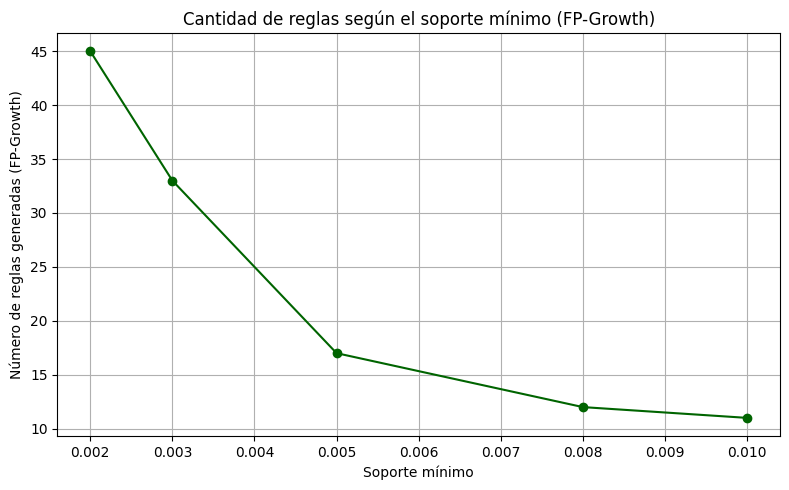

In [ ]:
from mlxtend.frequent_patterns import fpgrowth, association_rules
import matplotlib.pyplot as plt

# Lista de valores de soporte a probar
min_supports = [0.01, 0.008, 0.005, 0.003, 0.002]
num_rules_fp = []

# Generar reglas con distintos niveles de soporte usando FP-Growth
for support in min_supports:
    # Obtener itemsets frecuentes con FP-Growth
    itemsets_fp = fpgrowth(basket_df, min_support=support, use_colnames=True)

    # Generar reglas de asociación a partir de los itemsets
    rules_fp = association_rules(itemsets_fp, metric="confidence", min_threshold=0.5)

    # Guardar la cantidad de reglas generadas
    num_rules_fp.append(len(rules_fp))

# Visualizar en una gráfica
plt.figure(figsize=(8, 5))
plt.plot(min_supports, num_rules_fp, marker='o', color='darkgreen')
plt.title("Cantidad de reglas según el soporte mínimo (FP-Growth)")
plt.xlabel("Soporte mínimo")
plt.ylabel("Número de reglas generadas (FP-Growth)")
plt.grid(True)
plt.tight_layout()
plt.show()


#### Confianza mínima.

##### Apriori.

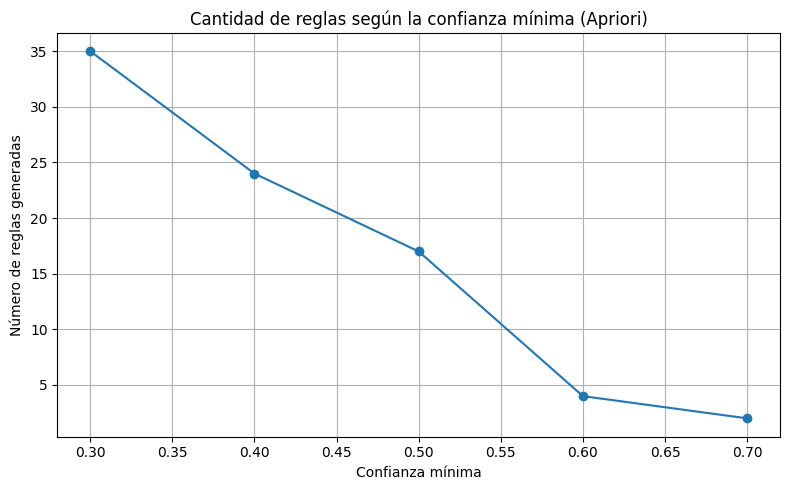

In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt

# Lista de valores de confianza mínima a probar
confianzas = [0.3, 0.4, 0.5, 0.6, 0.7]
num_reglas_confi = []

itemsets = apriori(basket_df.astype(bool), min_support=0.005, use_colnames=True)

for con in confianzas:
    reglas = association_rules(itemsets, metric="confidence", min_threshold=con)
    num_reglas_confi.append(len(reglas))

#Gráfico
plt.figure(figsize=(8, 5))
plt.plot(confianzas, num_reglas_confi, marker = 'o')
plt.title("Cantidad de reglas según la confianza mínima (Apriori)")
plt.xlabel("Confianza mínima")
plt.ylabel("Número de reglas generadas")
plt.grid(True)
plt.tight_layout()
plt.show()

##### FP-Growth.

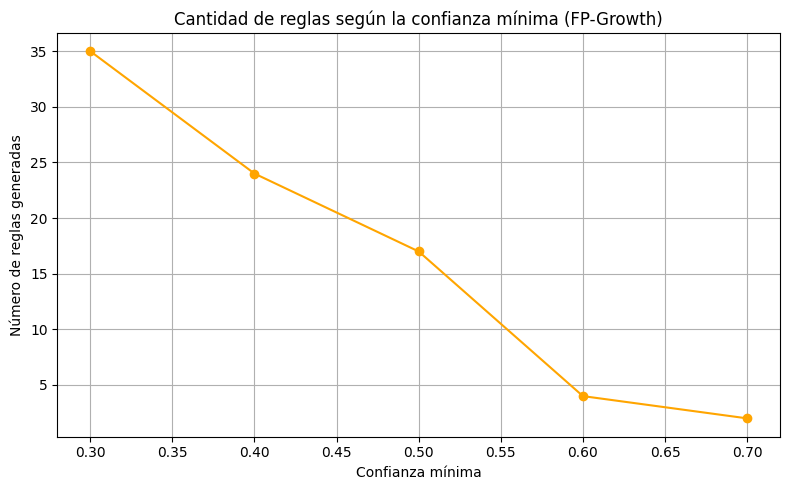

In [ ]:
from mlxtend.frequent_patterns import fpgrowth, association_rules
import matplotlib.pyplot as plt

# Lista de valores de confianza mínima a probar
confidence_thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
num_rules_conf_fp = []

# Generar itemsets frecuentes una sola vez con soporte fijo
frequent_itemsets_fp = fpgrowth(basket_df, min_support=0.005, use_colnames=True)

# Generar reglas con distintas confianzas mínimas
for conf in confidence_thresholds:
    rules = association_rules(frequent_itemsets_fp, metric="confidence", min_threshold=conf)
    num_rules_conf_fp.append(len(rules))

# Visualización
plt.figure(figsize=(8, 5))
plt.plot(confidence_thresholds, num_rules_conf_fp, marker='o', color='orange')
plt.title("Cantidad de reglas según la confianza mínima (FP-Growth)")
plt.xlabel("Confianza mínima")
plt.ylabel("Número de reglas generadas")
plt.grid(True)
plt.tight_layout()
plt.show()


#### Lift.

##### Apriori.

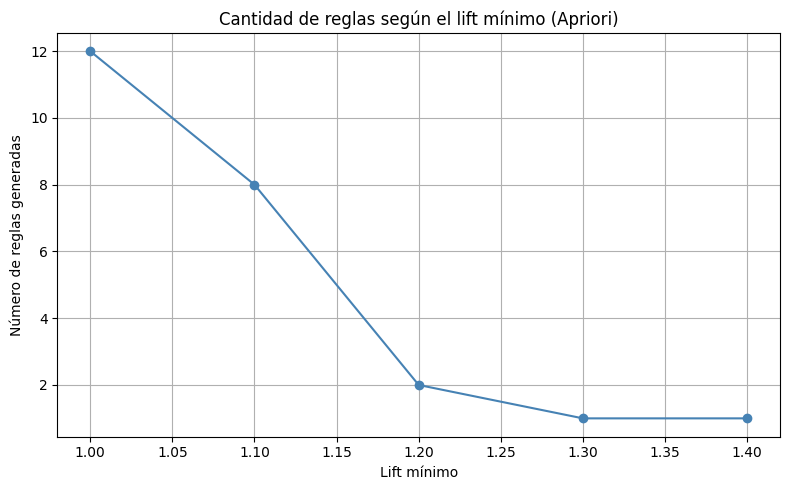

In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt

# Lista de valores de lift mínimo a evaluar
lift_thresholds = [1.0, 1.1, 1.2, 1.3, 1.4]
num_rules_lift_apriori = []

# Generar itemsets frecuentes una vez (con soporte y confianza fijos)
frequent_itemsets_apriori = apriori(basket_df, min_support=0.008, use_colnames=True)
rules_apriori = association_rules(frequent_itemsets_apriori, metric="confidence", min_threshold=0.5)

# Filtrar reglas por lift
for lift in lift_thresholds:
    filtered_rules = rules_apriori[rules_apriori["lift"] >= lift]
    num_rules_lift_apriori.append(len(filtered_rules))

# Visualización
plt.figure(figsize=(8, 5))
plt.plot(lift_thresholds, num_rules_lift_apriori, marker='o', color='steelblue')
plt.title("Cantidad de reglas según el lift mínimo (Apriori)")
plt.xlabel("Lift mínimo")
plt.ylabel("Número de reglas generadas")
plt.grid(True)
plt.tight_layout()
plt.show()


##### FP-Growth.

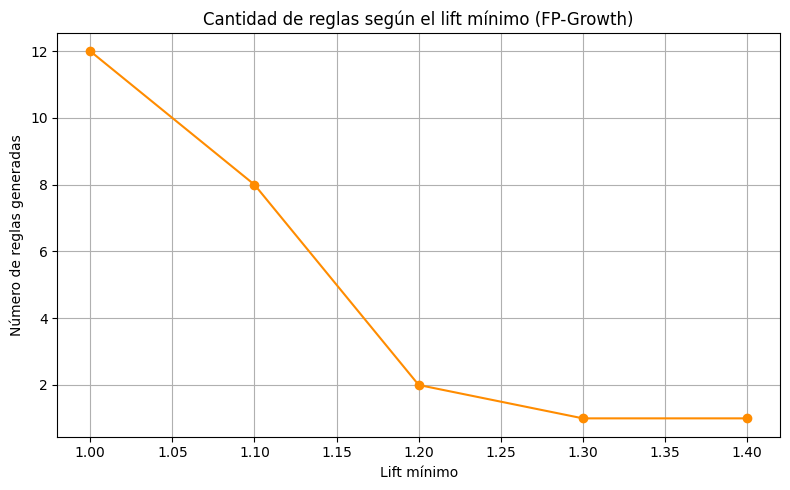

In [ ]:
from mlxtend.frequent_patterns import fpgrowth, association_rules

# Lista de valores de lift mínimo
lift_thresholds = [1.0, 1.1, 1.2, 1.3, 1.4]
num_rules_lift_fp = []

# Generar itemsets frecuentes una vez
frequent_itemsets_fp = fpgrowth(basket_df, min_support=0.008, use_colnames=True)
rules_fp = association_rules(frequent_itemsets_fp, metric="confidence", min_threshold=0.5)

# Filtrar por lift mínimo
for lift in lift_thresholds:
    filtered_rules = rules_fp[rules_fp["lift"] >= lift]
    num_rules_lift_fp.append(len(filtered_rules))

# Visualización
plt.figure(figsize=(8, 5))
plt.plot(lift_thresholds, num_rules_lift_fp, marker='o', color='darkorange')
plt.title("Cantidad de reglas según el lift mínimo (FP-Growth)")
plt.xlabel("Lift mínimo")
plt.ylabel("Número de reglas generadas")
plt.grid(True)
plt.tight_layout()
plt.show()


### TAREA 6: ENTRENAMIENTO Y ESTIMACIÓN DEL ERROR FUERA DE LA MUESTRA. DISCUSIÓN DE RESULTADOS Y EXTRACCIÓN DE CONCLUSIONES. SE DEBERÁ INCLUIR UN ESTUDIO DEL TIMEPO DE EJECUCIÓN DE LOS ALGORITMOS SELECCIONADOS PARA EXTRACCIÓN DE ITEMSETS FRECUENTES.

En esta sección se examinan los resultados finales tras aplicar los algoritmos Apriori y FP-Growth para la extracción de itemsets frecuentes. Se han utilizado los siguientes hiperparámetros ajustados:

Soporte mínimo (min_support): 0.0085

Confianza mínima (min_confidence): 0.5

Lift mínimo (min_lift): 1.1

Estos valores permiten filtrar reglas más relevantes y reducir aquellas con bajo valor informativo.



In [ ]:
# Parámetros finales
min_support = 0.005
min_confidence = 0.5
min_lift = 1.2

# Obtener itemsets frecuentes
itemsets_ap = apriori(basket_df.astype(bool), min_support=min_support, use_colnames=True)
itemsets_fp = fpgrowth(basket_df.astype(bool), min_support=min_support, use_colnames=True)

# Generar reglas
rules_ap = association_rules(itemsets_ap, metric="confidence", min_threshold=min_confidence)
rules_fp = association_rules(itemsets_fp, metric="confidence", min_threshold=min_confidence)

# Filtrar por lift
rules_ap = rules_ap[rules_ap["lift"] >= min_lift]
rules_fp = rules_fp[rules_fp["lift"] >= min_lift]


In [ ]:
# Seleccionar columnas útiles
reglas_mostrar = rules_fp[["antecedents", "consequents", "support", "confidence", "lift"]].copy()

# Convertir sets a strings para que se vean bien
reglas_mostrar['antecedents'] = reglas_mostrar['antecedents'].apply(lambda x: ', '.join(list(x)))
reglas_mostrar['consequents'] = reglas_mostrar['consequents'].apply(lambda x: ', '.join(list(x)))

# Ordenar por lift descendente y mostrar
reglas_mostrar.sort_values(by='lift', ascending=False)

,antecedents,consequents,support,confidence,lift
9,Toast,Coffee,0.023746,0.704403,1.467453
11,Spanish Brunch,Coffee,0.010919,0.598837,1.247533
3,Medialuna,Coffee,0.035302,0.569231,1.185856
2,Pastry,Coffee,0.047705,0.552147,1.150266
8,Tiffin,Coffee,0.008481,0.547945,1.141512
7,Alfajores,Coffee,0.019718,0.540698,1.126414
4,Juice,Coffee,0.020672,0.534247,1.112974
6,Sandwich,Coffee,0.038376,0.532353,1.109029
5,Cake,Coffee,0.054914,0.526958,1.097791
10,Scone,Coffee,0.018128,0.522936,1.089411


#### Conclusiones finales.

A lo largo de este trabajo se han aplicado dos algoritmos clásicos para la extracción de reglas de asociación: Apriori y FP-Growth, sobre un conjunto de datos transaccionales reales correspondientes a una panadería. El objetivo principal ha sido obtener reglas significativas que permitan descubrir patrones de compra recurrentes entre los clientes, así como evaluar y comparar el rendimiento y eficiencia de ambos algoritmos.

Desde el punto de vista del preprocesado, fue necesario transformar los datos a un formato de cesta o basket format mediante la codificación con TransactionEncoder, eliminando previamente aquellos registros no válidos (como NONE, Adjustment y Afternoon with the baker). Este paso fue esencial para garantizar la fiabilidad de las reglas extraídas.

En cuanto al protocolo de validación experimental, se utilizaron métricas internas propias del aprendizaje no supervisado, dado que no se cuenta con una verdad de referencia (ground truth) contra la cual validar las predicciones. Se analizaron principalmente cuatro métricas:

- Soporte, como medida de frecuencia;

- Confianza, para evaluar la probabilidad condicional de compra conjunta;

- Lift, como indicador del valor añadido respecto a la independencia;

- Y convicción, como medida complementaria de interés.

Estas métricas permitieron no solo filtrar las reglas más relevantes, sino también comparar el comportamiento de ambos algoritmos en términos de cantidad, calidad e interpretabilidad de las reglas generadas.

Durante la estimación de hiperparámetros, se observó cómo un menor soporte mínimo permite capturar patrones más raros, aunque con mayor riesgo de ruido, mientras que umbrales más altos tienden a generar reglas más generales. Lo mismo ocurrió con el parámetro de confianza mínima, donde se evidenció una clara relación inversa entre el valor del umbral y la cantidad de reglas obtenidas. El parámetro de lift mínimo sirvió como un filtro eficaz para priorizar las reglas más sólidas y significativas.

En cuanto al rendimiento computacional, el estudio del tiempo de ejecución utilizando %timeit demostró que FP-Growth supera considerablemente a Apriori en términos de eficiencia. Esto se debe a su estructura optimizada basada en árboles FP, que permite evitar la generación explícita de candidatos. A pesar de que ambos algoritmos produjeron reglas de calidad comparable, FP-Growth resultó mucho más escalable y adecuado para datasets de mayor tamaño.

A nivel cualitativo, las reglas más destacadas muestran patrones esperables en contextos de compra, como la alta probabilidad de adquirir Coffee junto a Pastry, Cake o Muffin, lo cual confirma la utilidad práctica de este tipo de técnicas para la toma de decisiones comerciales, como la planificación de ofertas, promociones cruzadas o distribución de productos.

#### Consideraciones finales.

Este análisis ha demostrado que la minería de reglas de asociación es una técnica poderosa y flexible para el descubrimiento de conocimiento en bases de datos transaccionales. La correcta elección de algoritmos, parámetros y métricas de evaluación permite no solo generar reglas válidas y útiles, sino también optimizar el proceso de extracción para adaptarlo a los requerimientos computacionales y estratégicos de cada caso de uso.

Por tanto, se concluye que:

- FP-Growth es preferible en contextos donde la eficiencia es crítica, manteniendo la calidad de las reglas;

- Apriori sigue siendo una excelente opción para análisis más pequeños o educativos, por su facilidad de implementación y comprensión;

- Y que una evaluación basada en múltiples métricas y análisis visuales complementarios permite una mejor toma de decisiones en la interpretación y selección de reglas.